<a href="https://colab.research.google.com/github/AndreNaufaldi29/23423019_Andre-Naufaldi_UTS_Visi-Komputer/blob/main/Andre_Naufaldi_23423019_uts_visikompueripynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload gambar daun selada...


Saving kopfsalatbutterhead-grupperoh-lactuca-sativa-var-capitata-lettucebutterheadincludes-boston-and-bibb-typesraw.jpg.jfif to kopfsalatbutterhead-grupperoh-lactuca-sativa-var-capitata-lettucebutterheadincludes-boston-and-bibb-typesraw.jpg.jfif
===== HASIL EKSTRAKSI CIRI =====
Luas       : 174097.0
Keliling   : 1724.0
Panjang    : 324
Lebar      : 540


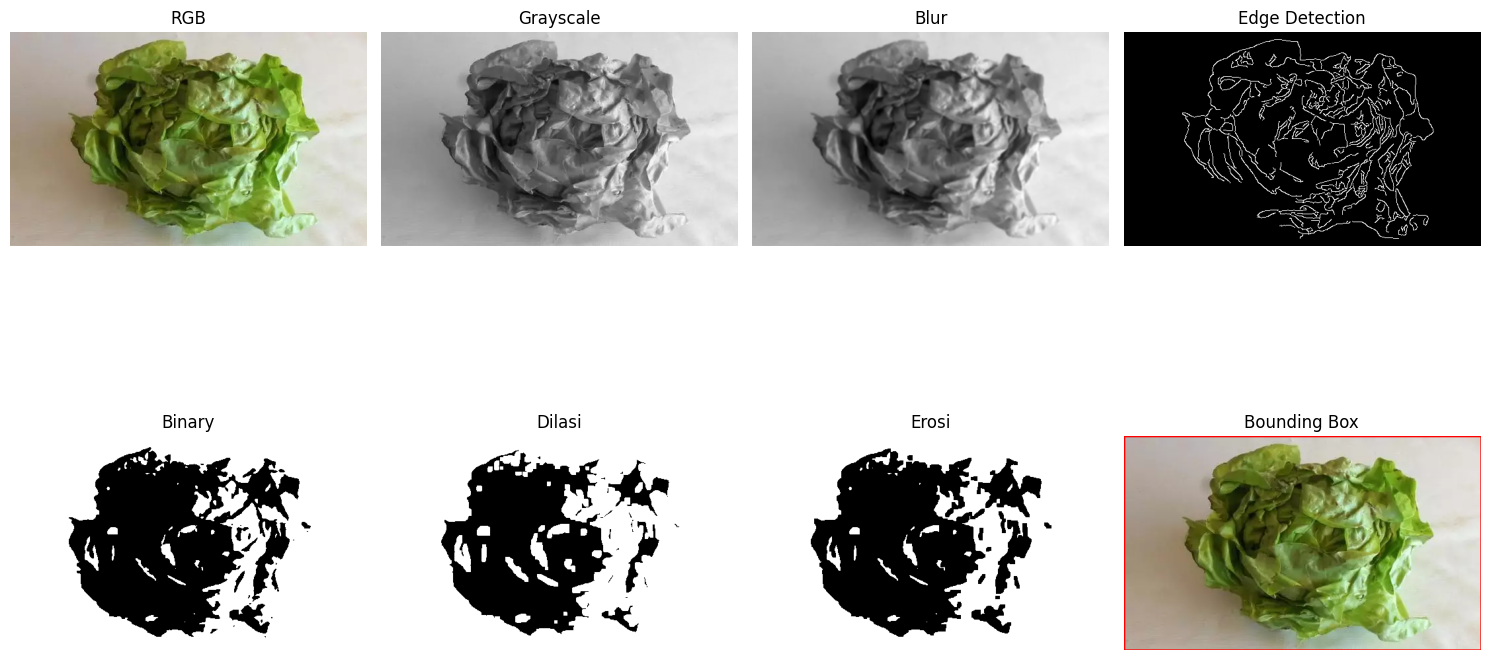

In [1]:
# ==========================================
# PENGOLAHAN CITRA DAUN SELADA (FULL CODE)
# ==========================================

# 1. Import Library
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ==========================================
# 2. Upload Gambar
# ==========================================
print("Upload gambar daun selada...")
uploaded = files.upload()

# Ambil nama file pertama
import os
filename = list(uploaded.keys())[0]

# Baca gambar
img = cv2.imread(filename)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ==========================================
# 3. Grayscale
# ==========================================
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# ==========================================
# 4. Blurring (Gaussian Blur)
# ==========================================
blur = cv2.GaussianBlur(gray, (5,5), 0)

# ==========================================
# 5. Edge Detection (Canny)
# ==========================================
edges = cv2.Canny(blur, 50, 150)

# ==========================================
# 6. Threshold (Binary)
# ==========================================
_, thresh = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY)

# Jika objek putih terbalik, aktifkan ini:
# thresh = cv2.bitwise_not(thresh)

# ==========================================
# 7. Operasi Morfologi (Dilasi & Erosi)
# ==========================================
kernel = np.ones((5,5), np.uint8)

dilasi = cv2.dilate(thresh, kernel, iterations=1)
erosi = cv2.erode(dilasi, kernel, iterations=1)

# ==========================================
# 8. Ekstraksi Ciri
# ==========================================
contours, _ = cv2.findContours(erosi, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if len(contours) == 0:
    print("Tidak ada objek terdeteksi!")
else:
    # Ambil objek terbesar
    cnt = max(contours, key=cv2.contourArea)

    # Luas
    area = cv2.contourArea(cnt)

    # Keliling
    perimeter = cv2.arcLength(cnt, True)

    # Bounding box
    x, y, w, h = cv2.boundingRect(cnt)

    print("===== HASIL EKSTRAKSI CIRI =====")
    print("Luas       :", area)
    print("Keliling   :", perimeter)
    print("Panjang    :", h)
    print("Lebar      :", w)

    # ==========================================
    # 9. Visualisasi Bounding Box
    # ==========================================
    output = img_rgb.copy()
    cv2.rectangle(output, (x,y), (x+w, y+h), (255,0,0), 2)

# ==========================================
# 10. Tampilkan Semua Tahapan
# ==========================================
plt.figure(figsize=(15,10))

plt.subplot(2,4,1)
plt.imshow(img_rgb)
plt.title("RGB")
plt.axis('off')

plt.subplot(2,4,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis('off')

plt.subplot(2,4,3)
plt.imshow(blur, cmap='gray')
plt.title("Blur")
plt.axis('off')

plt.subplot(2,4,4)
plt.imshow(edges, cmap='gray')
plt.title("Edge Detection")
plt.axis('off')

plt.subplot(2,4,5)
plt.imshow(thresh, cmap='gray')
plt.title("Binary")
plt.axis('off')

plt.subplot(2,4,6)
plt.imshow(dilasi, cmap='gray')
plt.title("Dilasi")
plt.axis('off')

plt.subplot(2,4,7)
plt.imshow(erosi, cmap='gray')
plt.title("Erosi")
plt.axis('off')

if len(contours) > 0:
    plt.subplot(2,4,8)
    plt.imshow(output)
    plt.title("Bounding Box")
    plt.axis('off')

plt.tight_layout()
plt.show()